In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('final_data.csv')
df.head()

,PM2.5 (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³),Toluene (µg/m³),Xylene (µg/m³),...,MP-Xylene (µg/m³),AT (°C),RH (%),WS (m/s),WD (deg),SR (W/mt2),BP (mmHg),VWS (m/s),Month,AQI_Label
0,0.758181,-0.418832,-0.239623,0.398988,-0.687071,0.053854,-0.855273,-0.401137,-1.346117,-2.110376,...,-0.294984,-1.790803,0.773675,-0.882793,-0.318858,-0.694085,1.882801,0.751086,-1.597591,5
1,0.734291,-0.497807,-0.252630,0.622702,-0.808447,-0.040602,-0.834750,-0.434677,-1.348278,-2.135281,...,-0.168583,-1.797989,0.777419,-0.902209,-0.318858,-0.693736,1.878137,0.784631,-1.597591,5
2,0.676191,-0.414993,-0.214215,0.395217,-0.685014,-0.009117,-0.844006,0.219365,-1.328828,-2.143583,...,0.570072,-1.806374,0.776349,-0.863376,0.122589,-0.692898,1.882801,0.751086,-1.597591,5
3,0.648375,-0.483548,-0.271081,0.620188,-0.954509,-0.056345,-0.851249,0.185824,-1.343956,-2.019058,...,0.629322,-1.812362,0.770466,-0.902209,0.352559,-0.692689,1.876582,0.751086,-1.597591,5
4,0.618428,-0.510970,-0.272896,0.411556,-0.956566,-0.040602,-0.856883,-0.375981,-1.393662,-1.990002,...,-0.081683,-1.819549,0.769396,-0.630376,-0.341144,-0.693038,1.856371,0.717541,-1.597591,5


In [13]:
df.shape

(8784, 21)

In [14]:
#Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['AQI_Label'])
y = df['AQI_Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(7027, 20)
(1757, 20)


In [16]:
#training logistic regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Training Accuracy:", lr_model.score(X_train, y_train))
print("Testing Accuracy:", lr_model.score(X_test, y_test))

Training Accuracy: 0.9193112281201081
Testing Accuracy: 0.9038133181559477


In [17]:
# so we here we are performing hyperparameter tunning , bassically it is choosing the best settings to get best accuracy
#for doing it we are using GridSeachCV 
#it takees a list of values you want to try 
#train the model with every combination 
#tells you which combination is best 

#for LR model the parameters are 
#C          → controls regularization (prevents overfitting)
#solver     → algorithm used to optimize the model
#max_iter   → how many iterations to run

#C is called the regularization parameter — it controls how much the model tries to fit the training data.

#lbfgs  → works well for small/medium datasets
#saga   → works well for large datasets


In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'saga']
}

grid_search = GridSearchCV(LogisticRegression(max_iter=1000), 
                           param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

C:\Users\Harsh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Harsh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Harsh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Harsh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Harsh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best Parameters: {'C': 10, 'solver': 'lbfgs'}
Best Accuracy: 0.9672693033921729


In [19]:
# ConvergenceWarning: The max_iter was reached
# This just means the saga solver needed more iterations to finish. It's not an error — it just means saga wasn't the right choice for your data. And GridSearch already figured that out — it picked lbfgs! ✅

In [20]:
# Before tuning → 90.4%
# After tuning  → 96.7% 

In [21]:
#now retrain with best parameters
lr_best = LogisticRegression(C=10, solver='lbfgs', max_iter=1000, random_state=42)
lr_best.fit(X_train, y_train)

print("Training Accuracy:", lr_best.score(X_train, y_train))
print("Testing Accuracy:", lr_best.score(X_test, y_test))


Training Accuracy: 0.9795076134908212
Testing Accuracy: 0.974957313602732


In [22]:
#evaluating precision , recall, f1-score

from sklearn.metrics import classification_report, confusion_matrix

y_pred = lr_best.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.94      0.96       242
           1       0.98      0.99      0.98       348
           2       0.97      0.94      0.96       163
           3       0.96      0.99      0.98       493
           4       0.96      0.98      0.97       111
           5       0.98      0.98      0.98       400

    accuracy                           0.97      1757
   macro avg       0.97      0.97      0.97      1757
weighted avg       0.98      0.97      0.97      1757



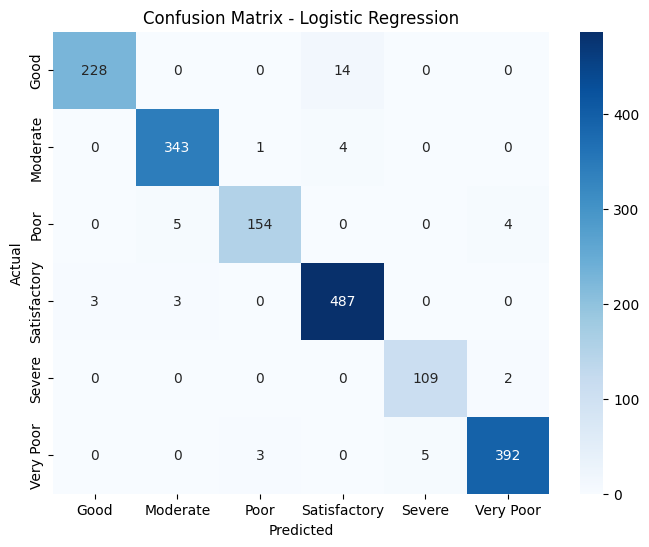

In [23]:
#confusion matrix 
labels = ['Good', 'Moderate', 'Poor', 'Satisfactory', 'Severe', 'Very Poor']

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

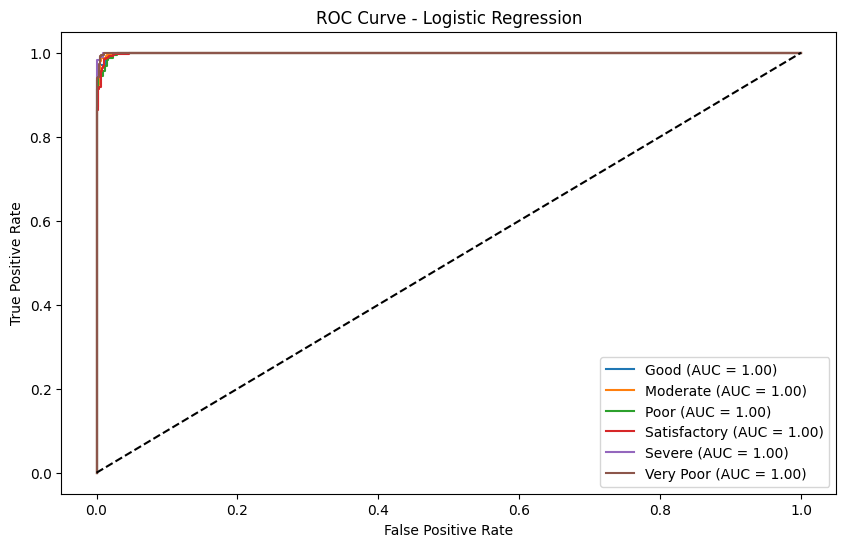

In [24]:
#ROC Curve 

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels
classes = [0, 1, 2, 3, 4, 5]
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_prob = lr_best.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(10, 6))
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [25]:
# lets start KNN 
#BERFORE knn has 
#these parameters n_neighbours -> how amny neighbors to look at 
#metric -> how to measure distance
#weights -> equal vote or closer = more vote

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

print("Training Accuracy:", knn_model.score(X_train, y_train))
print("Testing Accuracy:", knn_model.score(X_test, y_test))

Training Accuracy: 0.8605379251458659
Testing Accuracy: 0.7632327831531018


In [27]:
#here are two things ot notics 
#1st there is 10% gap btw training and testing which means sligh overfitting 
#which means k = 5 is too small - the model is mermorizing too much 

#2nd lower than LR

# so we know the default K = 5 is not teh best 
#so here we need hyperparameter tunning to fiond the optimal K

In [28]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), 
                        param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train, y_train)

print("Best Parameters:", grid_knn.best_params_)
print("Best Accuracy:", grid_knn.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best Accuracy: 0.8026189740967788


In [29]:
#now lets retrain the with best parameter 
knn_best = KNeighborsClassifier(
    metric='manhattan',
    n_neighbors=5,
    weights='distance'
)
knn_best.fit(X_train, y_train)

print("Training Accuracy:", knn_best.score(X_train, y_train))
print("Testing Accuracy:", knn_best.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.8127490039840638


In [30]:
knn_best2 = KNeighborsClassifier(
    metric='manhattan',
    n_neighbors=11,
    weights='distance'
)
knn_best2.fit(X_train, y_train)

print("Training Accuracy:", knn_best2.score(X_train, y_train))
print("Testing Accuracy:", knn_best2.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.8036425725668753


In [31]:
knn_best3 = KNeighborsClassifier(
    metric='manhattan',
    n_neighbors=11,
    weights='uniform'
)
knn_best3.fit(X_train, y_train)

print("Training Accuracy:", knn_best3.score(X_train, y_train))
print("Testing Accuracy:", knn_best3.score(X_test, y_test))

Training Accuracy: 0.8306531948199801
Testing Accuracy: 0.7842914058053501


In [32]:
# weights='distance' K=5  → Train:100%  Test:81.3% ❌ overfit
# weights='distance' K=11 → Train:100%  Test:80.4% ❌ overfit
# weights='uniform'  K=11 → Train:83.1% Test:78.4% ✅ balanced

In [33]:
# #so comparing with this the best parameters areknn_best = KNeighborsClassifier(
#     metric='manhattan',
#     n_neighbors=11,
#     weights='uniform'
# ) 

In [34]:
knn_final = KNeighborsClassifier(
    metric='manhattan',
    n_neighbors=11,
    weights='uniform'
)
knn_final.fit(X_train, y_train)

print("Training Accuracy:", knn_best3.score(X_train, y_train))
print("Testing Accuracy:", knn_best3.score(X_test, y_test))

Training Accuracy: 0.8306531948199801
Testing Accuracy: 0.7842914058053501


In [35]:
#now lets do the evaluation 


In [36]:
#evaluating precision , recall, f1-score

from sklearn.metrics import classification_report, confusion_matrix

y_pred = knn_final.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.72      0.76       242
           1       0.72      0.74      0.73       348
           2       0.66      0.54      0.59       163
           3       0.76      0.82      0.79       493
           4       0.91      0.79      0.85       111
           5       0.88      0.91      0.89       400

    accuracy                           0.78      1757
   macro avg       0.79      0.75      0.77      1757
weighted avg       0.78      0.78      0.78      1757



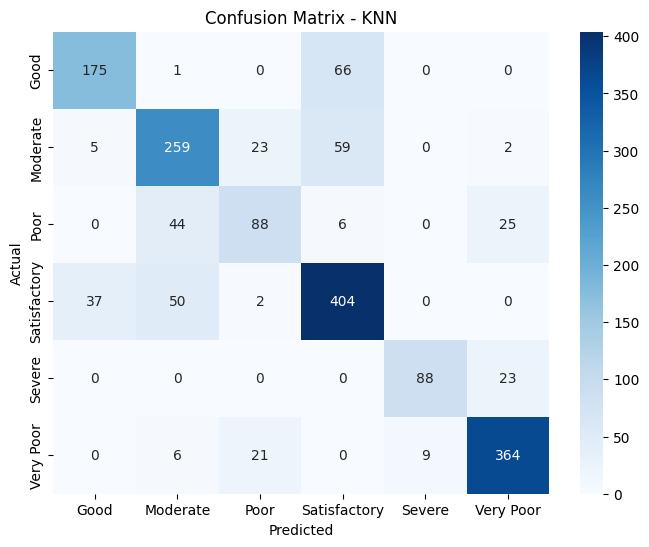

In [37]:
#confusion matrix 
labels = ['Good', 'Moderate', 'Poor', 'Satisfactory', 'Severe', 'Very Poor']

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - KNN')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

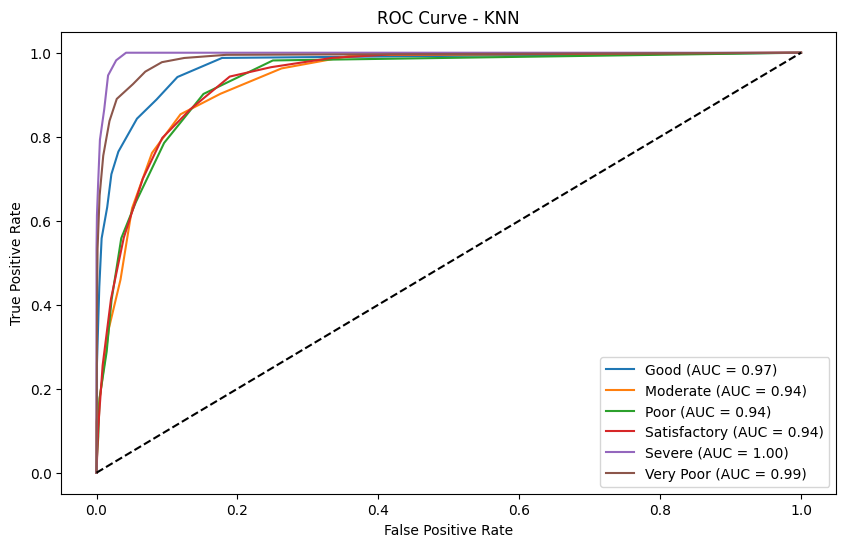

In [38]:
#ROC Curve 

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels
classes = [0, 1, 2, 3, 4, 5]
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_prob = knn_final.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(10, 6))
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - KNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [39]:
# lets compare so far 
# Model          Accuracy   F1    AUC
# Logistic Reg → 97.0%     0.97  1.00 🏆
# KNN          → 78.4%     0.77  0.94

In [40]:
# SVM tries to find the best boundary line (called a hyperplane) that separates classes with the maximum gap between them.
# Think of it like this:
# Logistic Regression → draws any line that separates classes
# SVM                 → draws the BEST line with maximum margin
# Like fitting the widest possible road between two neighborhoods! 🛣️

In [41]:
# SVM Key Hyperparameters:
# C       → regularization (same as LR)
# kernel  → shape of boundary
#          - linear  → straight line
#          - rbf     → curved boundary (most powerful)
#          - poly    → polynomial curve
# gamma   → how far each point's influence reaches

In [42]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

print("Training Accuracy:", svm_model.score(X_train, y_train))
print("Testing Accuracy:", svm_model.score(X_test, y_test))

Training Accuracy: 0.8874341824391633
Testing Accuracy: 0.8446215139442231


In [43]:
# #Comparison so far:
# Model          Accuracy
# LR           → 97.0% 🏆
# SVM          → 84.5%
# KNN          → 78.4%

In [44]:
#LETS PERFORM HYPERPARAMETER TUNNING


In [45]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(SVC(random_state=42, probability=True), 
                        param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train, y_train)

print("Best Parameters:", grid_svm.best_params_)
print("Best Accuracy:", grid_svm.best_score_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best Accuracy: 0.9810736902851531


In [46]:
# Surprising finding! 🤔
# linear kernel beat rbf! This tells us your data is linearly separable — meaning the classes can be separated with straight boundaries. That's actually a good sign about your data quality!

In [47]:
# Comparison after tuning:
# Model          Accuracy
# LR           → 97.0% 
# SVM          → 98.1% 🏆 new winner!
# KNN          → 78.4%

In [48]:
svm_best = SVC(C=10, gamma='scale', kernel='linear', 
               random_state=42, probability=True)
svm_best.fit(X_train, y_train)

print("Training Accuracy:", svm_best.score(X_train, y_train))
print("Testing Accuracy:", svm_best.score(X_test, y_test))

Training Accuracy: 0.9890422655471752
Testing Accuracy: 0.9857712009106432


In [49]:
#lets do the evaluation

In [50]:
#evaluating precision , recall, f1-score

from sklearn.metrics import classification_report, confusion_matrix

y_pred = svm_best.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97       242
           1       0.99      0.99      0.99       348
           2       0.98      0.96      0.97       163
           3       0.98      0.99      0.99       493
           4       0.98      0.99      0.99       111
           5       0.99      0.99      0.99       400

    accuracy                           0.99      1757
   macro avg       0.99      0.98      0.98      1757
weighted avg       0.99      0.99      0.99      1757



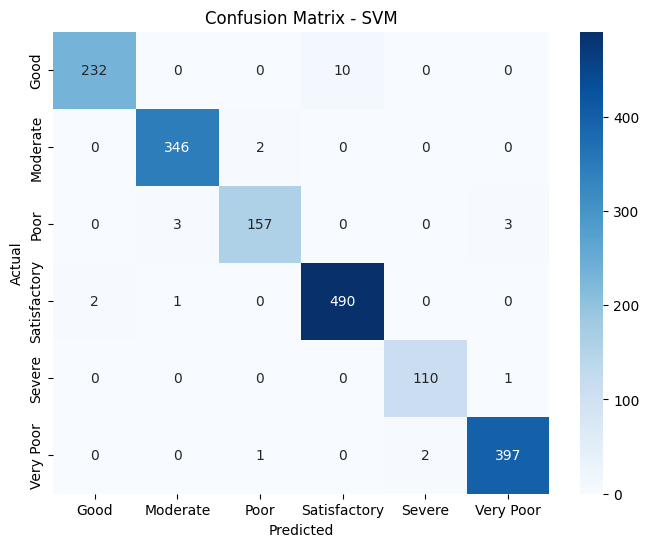

In [51]:
#confusion matrix 
labels = ['Good', 'Moderate', 'Poor', 'Satisfactory', 'Severe', 'Very Poor']

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

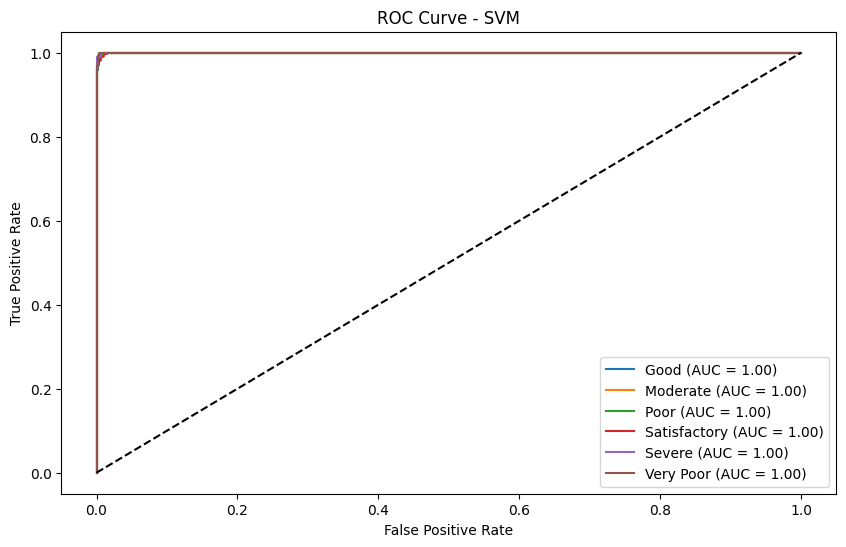

In [52]:
#ROC Curve 

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels
classes = [0, 1, 2, 3, 4, 5]
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_prob = svm_best.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(10, 6))
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - SVM')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [53]:
# Testing Accuracy → 98.6%
# F1-Score (avg)   → 0.98
# AUC (all)        → 1.00 🔥 Perfect!

In [54]:
# Model    Accuracy   F1     AUC
# LR     → 97.0%     0.97   1.00
# SVM    → 98.6%     0.98   1.00 🏆
# KNN    → 78.4%     0.77   0.94

In [55]:
# till here we have train all the model lets go to sir and get approval if we have done things right 

In [56]:
# after that we can save our data using joblib and then we ccan make a comparision chart btw all models 

In [57]:
#now we are doing modle comparison chart 

In [58]:
# What it helps you see:
# 1. Which model is clearly the best — one glance tells you SVM wins, no need to read through outputs
# 2. How big the gap is — you can SEE that KNN is far behind LR and SVM, not just know it
# 3. Consistency — is a model good at accuracy but bad at F1? The chart shows that instantly

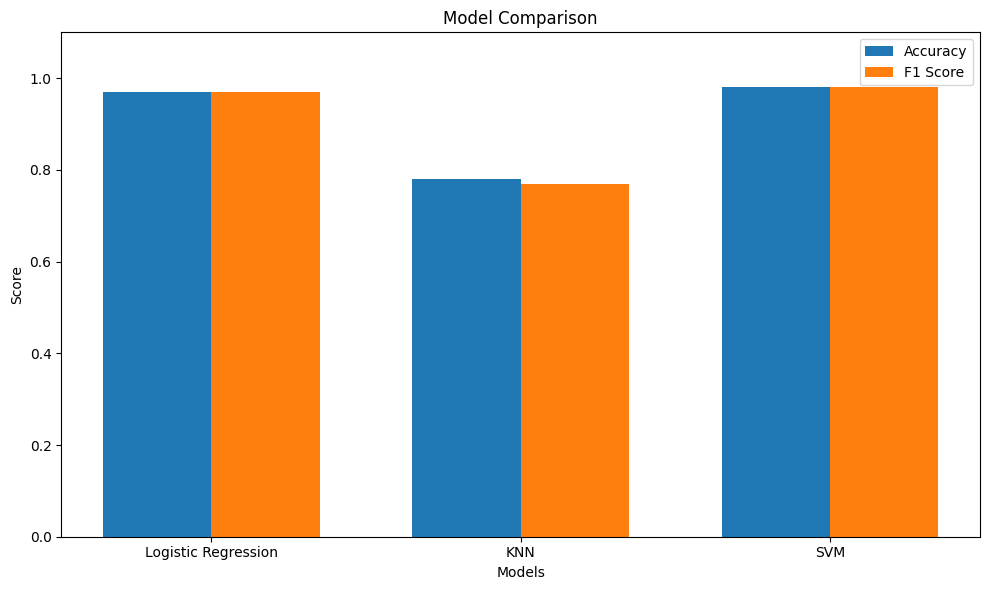

In [59]:
models = ['Logistic Regression', 'KNN', 'SVM']
accuracy = [0.97, 0.78, 0.98] 
f1_scores = [0.97,0.77,0.98]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score')

ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

In [60]:
#We are saving the trained models to files after training.

In [61]:
#why are we doing this
#1.Avoid Retraining Again and Again
#2.Protect Your Work: If notebook crashes or code breaks later, trained model is still safe

In [62]:
import joblib

# Save all models
joblib.dump(lr_best, 'lr_model.pkl')
joblib.dump(knn_final, 'knn_model.pkl')
joblib.dump(svm_best, 'svm_model.pkl')

print("Models saved successfully!")

Models saved successfully!
